In [54]:
import pyodbc
import pandas as pd

conn=pyodbc.connect(
    'DRIVER={odbc driver 18 for sql server};'
    'SERVER=LAPTOP-HG9M2VJS;'
    'DATABASE=ai_student;'
    'TrustServerCertificate=yes;'
    'Trusted_Connection=yes;'

)

query = "SELECT * FROM ai_student_impact_dataset"

df = pd.read_sql(query, conn)

print(df.head())

C:\Users\Aarya Khire\AppData\Local\Temp\ipykernel_5648\699588740.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


   Student_ID Major_Category Year_of_Study  Pre_Semester_GPA  \
0      100001     Humanities        Senior             2.418   
1      100002        Medical        Junior             3.821   
2      100003       Business      Freshman             3.398   
3      100004       Business        Senior             3.789   
4      100005           STEM     Sophomore             3.635   

   Weekly_GenAI_Hours           Primary_Use_Case Prompt_Engineering_Skill  \
0           23.309999       Copywriting/Drafting                 Beginner   
1            1.120000                   Ideation                 Advanced   
2           21.260000        Summarizing_Reading                 Beginner   
3            1.820000       Copywriting/Drafting             Intermediate   
4            9.290000  Debugging/Troubleshooting                 Advanced   

   Tool_Diversity  Paid_Subscription  Traditional_Study_Hours  \
0               1               True                     8.13   
1               5     

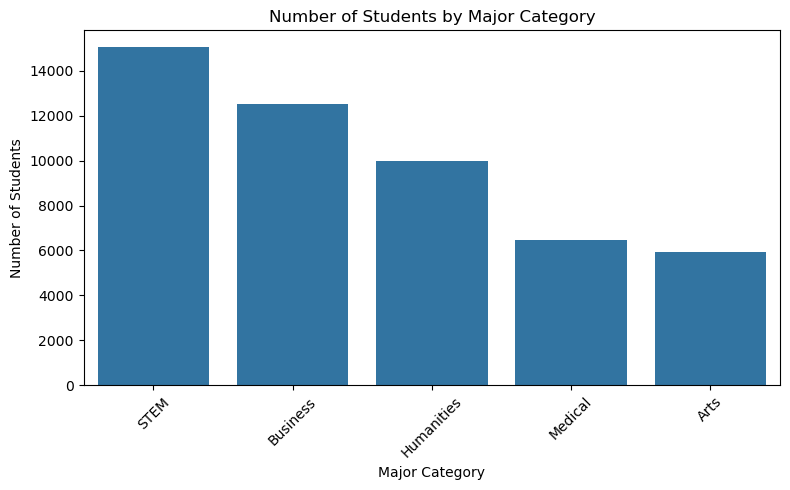

In [ ]:
#Which major category has the highest number of students?
major_counts = df['Major_Category'].value_counts()
plt.figure(figsize=(8, 5))
sns.barplot(x=major_counts.index, y=major_counts.values)
plt.title('Number of Students by Major Category')
plt.xlabel('Major Category')
plt.ylabel('Number of Students')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [57]:
#What percentage of students have paid subscriptions?visualize the distribution of subscription status among students.

subscription_counts = df['Paid_Subscription'].value_counts()
subscription_percentages = subscription_counts / subscription_counts.sum() * 100
print(subscription_percentages)



Paid_Subscription
False    57.692
True     42.308
Name: count, dtype: float64


In [85]:
#Is there a correlation between skill retention and post-semester performance?
correlation = df["Skill_Retention_Score"].corr(df["Post_Semester_GPA"])
print(f"Correlation between skill retention and post-semester performance: {correlation:.2f}")


Correlation between skill retention and post-semester performance: 0.17


   Paid_Subscription  Post_Semester_GPA
0              False           3.346953
1               True           3.352499


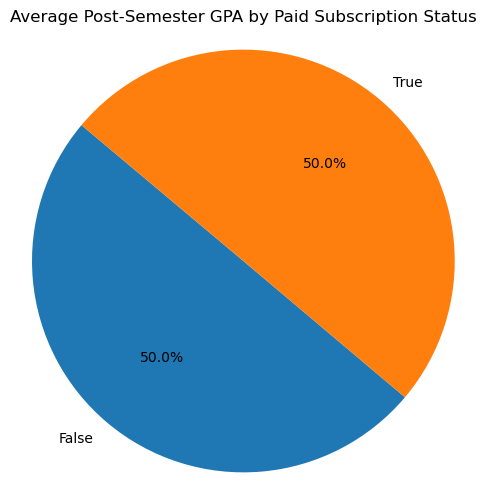

In [88]:
#Does paid subscription usage increase productivity?

avg_gpa_by_subscription = df.groupby("Paid_Subscription")["Post_Semester_GPA"].mean().reset_index()
print(avg_gpa_by_subscription)


#give pie chart
plt.figure(figsize=(6, 6))
plt.pie(avg_gpa_by_subscription["Post_Semester_GPA"], labels=avg_gpa_by_subscription["Paid_Subscription"], autopct='%1.1f%%', startangle=140)
plt.title("Average Post-Semester GPA by Paid Subscription Status")
plt.axis('equal')
plt.show()




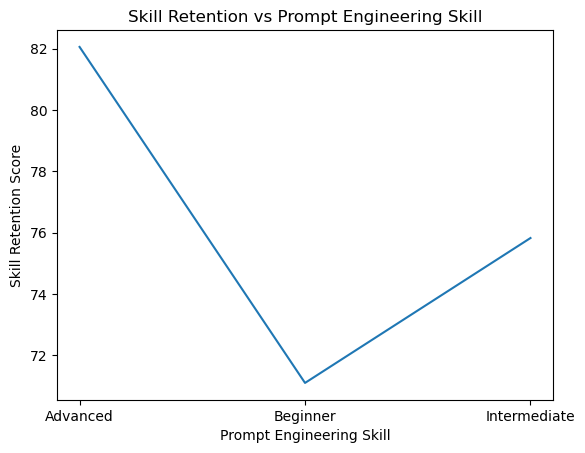

In [90]:
#Is prompt engineering improving academic efficiency?
avg_efficiency_by_prompt = df.groupby("Prompt_Engineering_Skill")["Skill_Retention_Score"].mean().reset_index()
sns.lineplot(x="Prompt_Engineering_Skill", y="Skill_Retention_Score", data=avg_efficiency_by_prompt)
plt.title("Skill Retention vs Prompt Engineering Skill")
plt.xlabel("Prompt Engineering Skill")
plt.ylabel("Skill Retention Score")
plt.show()

In [92]:
#update and close connection
conn.close()